# 01 — Data Exploration
Uses the SAME data loading code as the backend (`app.ml.data_loader`) — no duplicate implementation. Data is SYNTHETIC DEMONSTRATION DATA.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../backend'))
import matplotlib.pyplot as plt
import pandas as pd
from app.ml.data_loader import generate_synthetic_dataset, TARGET_COLUMN
# n_athletes defaults to settings.synthetic_dataset_size (10,000) when omitted
from app.config import settings
df = generate_synthetic_dataset(seed=settings.random_state)
df.shape

(10000, 35)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   athlete_id                  10000 non-null  str    
 1   age                         10000 non-null  int64  
 2   gender                      10000 non-null  str    
 3   sport                       10000 non-null  str    
 4   event_type                  10000 non-null  str    
 5   height                      10000 non-null  float64
 6   weight                      10000 non-null  float64
 7   experience_years            10000 non-null  int64  
 8   training_hours_per_week     10000 non-null  float64
 9   training_frequency          10000 non-null  int64  
 10  training_intensity          10000 non-null  int64  
 11  weekly_distance_km          10000 non-null  float64
 12  long_run_distance_km        10000 non-null  float64
 13  speed_work_sessions         10000 non-null 

In [3]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,age,height,weight,experience_years,training_hours_per_week,training_frequency,training_intensity,weekly_distance_km,long_run_distance_km,speed_work_sessions,...,recovery_days,rest_days,stress_level,hydration_score,nutrition_score,previous_injury,injury_count,days_since_previous_injury,previous_recovery_duration,injury_next_7_days
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,30.39290,171.10951,61.868350,14.942300,6.47530,4.503000,6.353000,44.794240,11.44850,2.215200,...,1.478100,1.503200,5.489200,69.831250,69.847890,0.404100,1.218100,2338.090800,25.017500,0.236900
std,8.61157,9.06707,8.956519,8.860001,2.61475,1.714901,2.129517,20.916173,7.58903,1.196926,...,1.108622,1.123795,2.868014,14.603348,14.612151,0.490742,1.730154,1599.849233,37.234111,0.425202
min,16.00000,145.00000,40.000000,0.000000,1.00000,2.000000,1.000000,5.000000,2.00000,0.000000,...,0.000000,0.000000,1.000000,8.500000,9.200000,0.000000,0.000000,10.000000,0.000000,0.000000
25%,23.00000,165.00000,55.800000,7.000000,4.60000,3.000000,5.000000,28.500000,5.20000,1.000000,...,0.000000,0.000000,3.000000,60.000000,59.900000,0.000000,0.000000,498.000000,0.000000,0.000000
50%,30.00000,171.10000,61.800000,15.000000,6.30000,5.000000,6.000000,42.200000,9.50000,2.000000,...,1.000000,2.000000,6.000000,70.000000,70.100000,0.000000,0.000000,3650.000000,0.000000,0.000000
75%,38.00000,177.20000,67.900000,22.000000,8.30000,6.000000,8.000000,59.700000,16.90000,3.000000,...,2.000000,3.000000,8.000000,80.000000,80.000000,1.000000,2.000000,3650.000000,48.000000,0.000000
max,45.00000,205.00000,100.000000,33.000000,16.70000,7.000000,10.000000,132.000000,42.00000,5.000000,...,3.000000,3.000000,10.000000,100.000000,100.000000,1.000000,5.000000,3650.000000,119.000000,1.000000


In [6]:
df[TARGET_COLUMN].value_counts(normalize=True)

injury_next_7_days
0    0.7631
1    0.2369
Name: proportion, dtype: float64

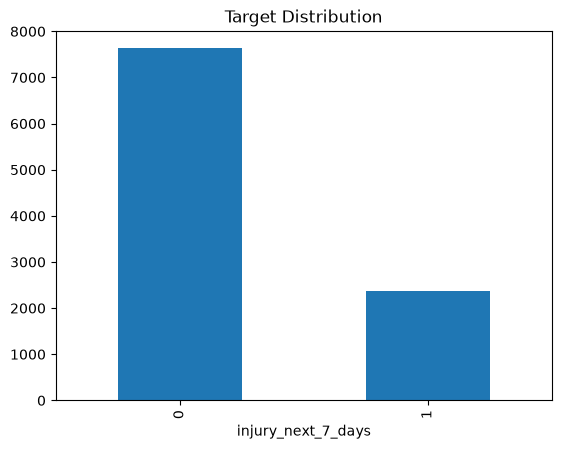

In [7]:
df[TARGET_COLUMN].value_counts().plot(kind='bar', title='Target Distribution')
plt.show()

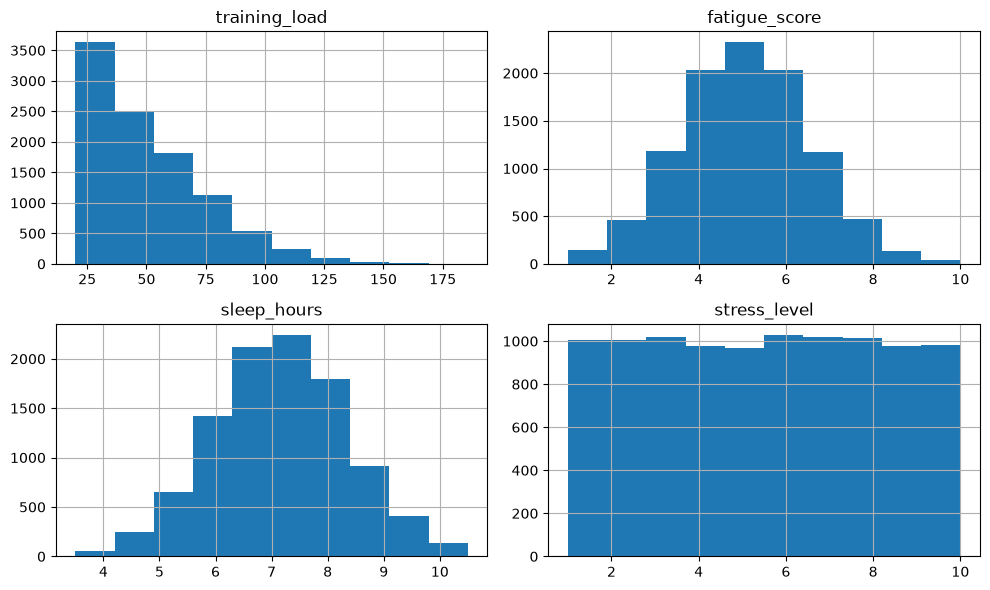

In [8]:
df[['training_load','fatigue_score','sleep_hours','stress_level']].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

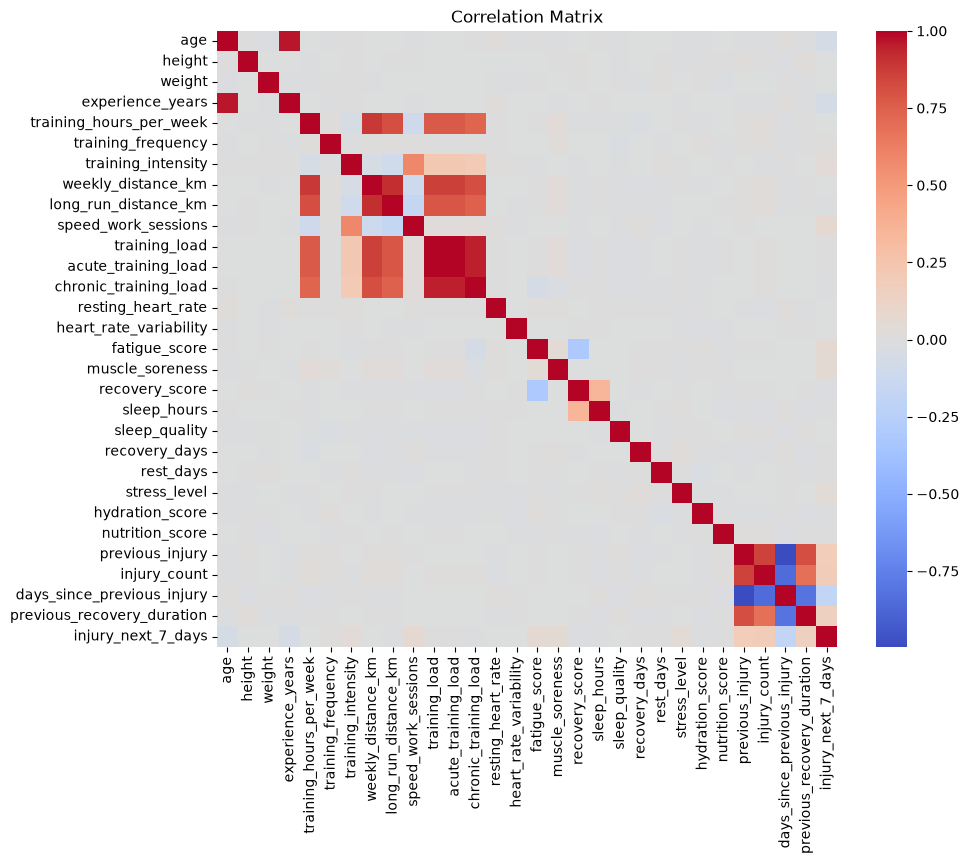

In [9]:
import seaborn as sns
corr = df.select_dtypes('number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [10]:
df.groupby(TARGET_COLUMN)[['fatigue_score','sleep_hours','training_load']].mean()

,fatigue_score,sleep_hours,training_load
injury_next_7_days,,,
0,4.960818,7.116734,49.939969
1,5.192908,7.081891,50.423217
